https://github.com/maxhully/GerryChain-Templates/blob/master/grids/GridChainSimple.ipynb

In [2]:

import random

import matplotlib.pyplot as plt
from functools import partial
import networkx as nx

from gerrychain import MarkovChain
from gerrychain.constraints import (
    Validator,
    single_flip_contiguous,
    within_percent_of_ideal_population,
)
from gerrychain.proposals import propose_random_flip
from gerrychain.accept import always_accept
from gerrychain.updaters import Election, Tally, cut_edges
from gerrychain.partition import Partition
from gerrychain.proposals import recom
from gerrychain.metrics import mean_median, efficiency_gap

In [ ]:
import numpy as np
from gerrychain import Graph

SEED = 42
random.seed(SEED); np.random.seed(SEED)

gn = 6;     # grid size (k x gn, k x gn)
k = 5;      # number of districts
ns = 50;    # population per node
p = 0.5     # probability of being pink vs purple


graph = nx.grid_graph([k * gn, k * gn])

for n in graph.nodes():
    graph.nodes[n]["population"] = 50
    if 0 in n or k * gn - 1 in n:
        graph.nodes[n]["boundary_node"]  = True
        graph.nodes[n]["boundary_perim"] = 1
    else:
        graph.nodes[n]["boundary_node"] = False

cddict     = {x: int(x[0] / gn) for x in graph.nodes()}
total_pop  = sum(graph.nodes[v]["population"] for v in graph.nodes())
pop_target = total_pop / k
gc_graph   = Graph.from_networkx(graph)

In [ ]:
from gerrychain.tree import recursive_tree_part

ideal_pop = total_pop / k

# Generate the random assignment
random_assignment = recursive_tree_part(
    graph=graph,
    parts=range(k),
    pop_target=ideal_pop,
    pop_col='population',
    epsilon=0.1
)

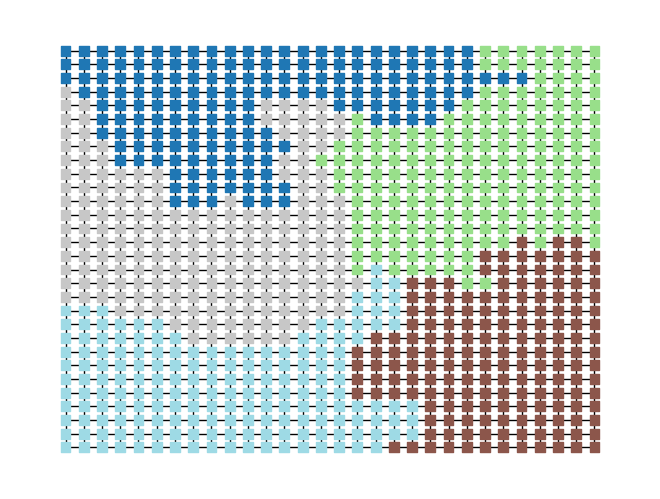

In [ ]:
plt.figure()
nx.draw(
    graph,
    pos={x: x for x in graph.nodes()},
    node_color=[random_assignment[x] for x in graph.nodes()],
    node_size=ns,
    node_shape="s",
    cmap="tab20",
)
plt.show()

In [ ]:
initial_partition = Partition(
    graph=graph,
    assignment=random_assignment,
    updaters={"cut_edges": cut_edges, "population": Tally("population"), "boundaries": Tally("boundary_node")},
)

In [7]:
district_boundaries = {}

# Iterate through all unique districts in the assignment
for d_id in set(initial_partition.assignment.values()):
    # Find nodes in this district that are part of any cut edge
    b_nodes = set()
    for u, v in initial_partition.cut_edges:
        if initial_partition.assignment[u] == d_id:
            b_nodes.add(u)
        elif initial_partition.assignment[v] == d_id:
            b_nodes.add(v)
    district_boundaries[d_id] = b_nodes

# Example: Print boundary nodes for district 0
print(f"Boundary nodes for District 0: {district_boundaries[0]}")

Boundary nodes for District 0: {(6, 18), (24, 27), (12, 19), (21, 25), (12, 22), (4, 21), (22, 26), (3, 22), (22, 29), (8, 18), (17, 24), (10, 18), (19, 24), (11, 23), (11, 20), (11, 26), (10, 24), (2, 23), (13, 26), (6, 20), (16, 25), (12, 18), (3, 21), (22, 28), (23, 27), (5, 21), (9, 19), (1, 26), (15, 25), (25, 27), (2, 25), (6, 19), (7, 18), (18, 24), (20, 24), (12, 26), (14, 26), (11, 21), (10, 25), (11, 18), (0, 27), (2, 24)}


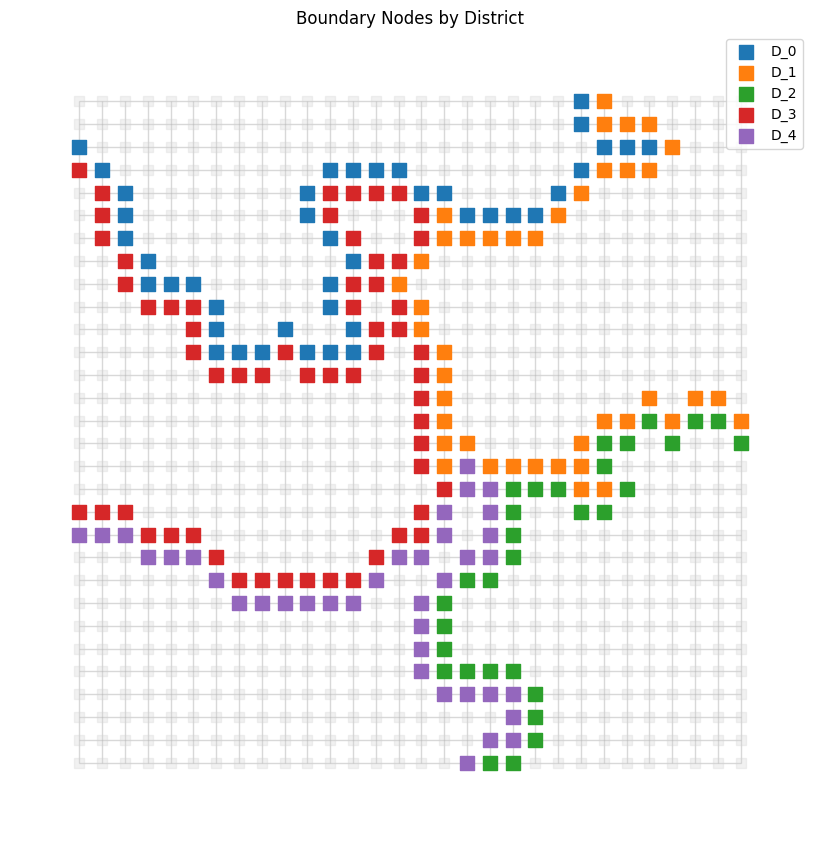

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

# The position of the nodes is just the coordinate tuple itself
pos = {node: node for node in initial_partition.graph.nodes}

plt.figure(figsize=(8, 8))

# 1. Draw the underlying graph (edges and all nodes)
nx.draw(
    initial_partition.graph, 
    pos=pos, 
    node_color="lightgray", 
    node_size=ns, 
    node_shape="s",
    edge_color="gray", 
    alpha=0.3,
    with_labels=False
)

# 2. Overlay the boundary nodes for each district with specific colors
colors = plt.cm.tab10.colors  # Use a standard color cycle
for d_id, b_nodes in district_boundaries.items():
    nx.draw_networkx_nodes(
        initial_partition.graph,
        pos=pos,
        nodelist=list(b_nodes),
        node_color=[colors[d_id % len(colors)]],
        node_size=100,
        node_shape="s",
        label=f"D_{d_id}"
    )

plt.legend()
plt.title("Boundary Nodes by District")
plt.gca().set_aspect('equal') # Keep the grid square
plt.show()


Rural areas -> districts 0 and 1 are randomly choosen.

In [ ]:
for node in initial_partition.parts[0]:
    graph.nodes[node]['density'] = 10
for node in initial_partition.parts[1]:
    graph.nodes[node]['density'] = 100
for node in initial_partition.parts[2]:
    graph.nodes[node]['density'] = 200
for node in initial_partition.parts[3]:
    graph.nodes[node]['density'] = 300  

In [ ]:
# 3 example plots

plt.figure()
nx.draw(graph, pos={x: x for x in graph.nodes()}, node_size=ns, node_shape="s")
plt.show()

cdict = {1: "pink", 0: "purple"}

plt.figure()
nx.draw(
    gc_graph,
    pos={x: x for x in graph.nodes()},
    node_color=[cdict[graph.nodes[x]["pink"]] for x in graph.nodes()],
    node_size=ns,
    node_shape="s",
)
plt.show()

plt.figure()
nx.draw(
    gc_graph,
    pos={x: x for x in graph.nodes()},
    node_color=[cddict[x] for x in graph.nodes()],
    node_size=ns,
    node_shape="s",
    cmap="tab20",
)
plt.show()

In [1]:
from gerrychain import Graph

graph = Graph.from_json("/Users/kirtisoglu/GitHub/Redistricting_Diffusion_Model/IA_counties.json")

In [2]:
#from gerrytools.scoring import *
from gerrytools.plotting import *
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


In [3]:
import random

node = random.choice(list(graph.nodes))
graph.nodes[node]

{'boundary_node': True,
 'boundary_perim': 0.45983509430284064,
 'area': 0.14555917832799964,
 'STATEFP10': '19',
 'COUNTYFP10': '185',
 'GEOID10': 19185,
 'NAME10': 'Wayne',
 'NAMELSAD10': 'Wayne County',
 'ALAND10': 1360874542,
 'AWATER10': 4441137,
 'INTPTLAT10': '+40.7399827',
 'INTPTLON10': '-093.3326126',
 'TOTPOP': 6403,
 'NH_WHITE': 6244,
 'NH_BLACK': 17,
 'NH_AMIN': 12,
 'NH_ASIAN': 15,
 'NH_NHPI': 1,
 'NH_OTHER': 0,
 'NH_2MORE': 45,
 'HISP': 69,
 'H_WHITE': 31,
 'H_BLACK': 1,
 'H_AMIN': 0,
 'H_ASIAN': 3,
 'N_NHPI': 0,
 'H_OTHER': 31,
 'H_2MORE': 3,
 'VAP': 4903,
 'HVAP': 37,
 'WVAP': 4816,
 'BVAP': 7,
 'AMINVAP': 8,
 'ASIANVAP': 12,
 'NHPIVAP': 0,
 'OTHERVAP': 0,
 '2MOREVAP': 23,
 'TOTVOT00': 3021,
 'PRES00D': 1300,
 'PRES00R': 1666,
 'PRES00G': 31,
 'PRES00OTH': 24,
 'TOTVOT04': 3133,
 'PRES04D': 1379,
 'PRES04R': 1733,
 'PRES04OTH': 21,
 'TOTVOT08': 2980,
 'PRES08D': 1357,
 'PRES08R': 1565,
 'PRES08OTH': 58,
 'TOTVOT12': 2900,
 'PRES12D': 1251,
 'PRES12R': 1583,
 'PRES12OTH

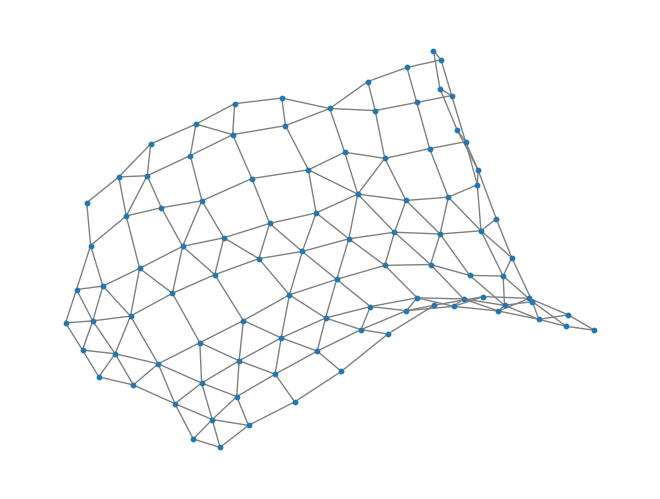

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt

# If the graph was created from a shapefile, it often has the geometry in nodes
# For a general plot of the dual graph layout:
import networkx as nx
nx.draw(graph, node_size=10, edge_color='gray')
plt.show()

https://colab.research.google.com/github/gerrymandr/gdbc/blob/master/exercises/gerrychain_iowa_demo.ipynb#scrollTo=ms31mkFEydU_

In [9]:
plan = gpd.read_file("/Users/kirtisoglu/GitHub/Redistricting_Diffusion_Model/IA_counties.zip")

<Axes: >

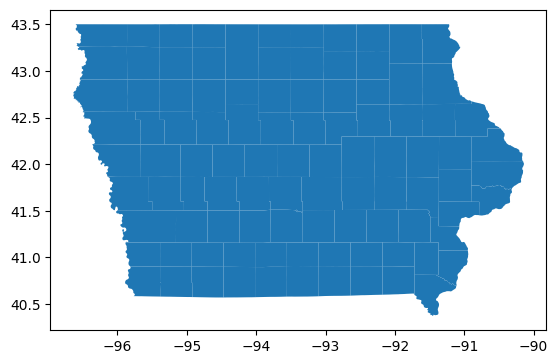

In [12]:
plan.plot()

In [ ]:
graph = Graph.from_file("IA_counties.shp")
graph.to_json("/Users/kirtisoglu/GitHub/Redistricting_Diffusion_Model/IA_counties/IA_counties.json")

0    1
1    2
2    3
3    4
Name: CD, dtype: object

In [17]:
#call the elections whatever you like
election_names = ["PRES00","PRES04","PRES08","PRES12"] 
#these have to be shapefile column names, in (Democrat, Republican) pairs
election_columns = [["PRES00D", "PRES00R"],["PRES04D", "PRES04R"],["PRES08D", "PRES08R"],["PRES12D","PRES12R"]]
#the population column on the shapefile
pop_col = "TOTPOP"

In [18]:
from gerrychain import Graph, Election, updaters, Partition, constraints, MarkovChain
from gerrychain.updaters import cut_edges
from gerrychain.proposals import recom, propose_random_flip
from gerrychain.tree import recursive_tree_part
from gerrychain.accept import always_accept
from gerrychain.constraints import single_flip_contiguous
from gerrychain.random import random
import pandas as pd
import numpy as np
from functools import partial
import matplotlib.pyplot as plt
import geopandas as gpd

#basic updaters
myupdaters = {
    "population": updaters.Tally(pop_col, alias="population"),
    "cut_edges": cut_edges,
}
#election updaters using GerryChain Election objects
elections = [
    Election(name,{"Democratic": dem, "Republican": rep})
    for name, (dem, rep) in zip(election_names, election_columns)
]
election_updaters = {election.name: election for election in elections}
myupdaters.update(election_updaters)

In [19]:
total_population = sum([graph.nodes[n][pop_col] for n in graph.nodes])
assignment = recursive_tree_part(
    graph, 
    range(4), #district names, in this case {0,1,2,3}
    total_population/4, #ideal population for a district
    pop_col, 
    0.05 #maximum allowed population deviation, 5% for now
)
#make a GerryChain Partition object
initial_partition = Partition(graph, assignment, myupdaters)

<Axes: >

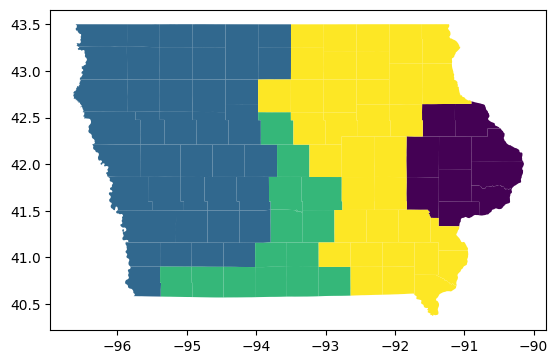

In [20]:
initial_partition.plot(plan)

In [27]:
plan['districts'] = 0
for index, row in plan.items():
    assignment = initial_partition.assignment[index]
    plan[row]['districts'] = assignment

KeyError: 'STATEFP10'

In [ ]:
import gerrytools
gerrytools.plotting.drawplan(plan, districts, overlays=[], colors=None, numbers=False, lw=0.5, fontsize=15, edgecolor='black')

KeyError: "None of [Index([ 5, 38,  8, 59, 10, 53, 24, 89, 27, 62,  2,  3, 12, 13, 14, 17, 18, 19,\n       20, 21, 26, 30, 32, 39, 41, 42, 43, 46, 49, 50, 52, 56, 57, 58, 60, 61,\n       64, 65, 66, 67, 69, 70, 72, 77, 79, 84, 87, 90, 91, 97, 34, 36, 68,  6,\n        7, 71, 73, 44, 47, 48, 54, 55, 22, 95,  0,  1,  4,  9, 11, 15, 16, 23,\n       25, 28, 29, 31, 33, 35, 37, 40, 45, 51, 63, 74, 75, 76, 78, 80, 81, 82,\n       83, 85, 86, 88, 92, 93, 94, 96, 98],\n      dtype='int64')] are in the [columns]"

In [21]:
plan.head()

,STATEFP10,COUNTYFP10,GEOID10,NAME10,NAMELSAD10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,TOTPOP,...,TOTVOT12,PRES12D,PRES12R,PRES12OTH,TOTVOT16,PRES16D,PRES16R,PRES16OTH,CD,geometry
0,19,127,19127,Marshall,Marshall County,1482770678,1803086,+42.0416910,-092.9814523,40648,...,19064,10257,8472,335,17980,7652,9146,1182,1,"POLYGON ((-92.76679 42.12346, -92.76679 42.122..."
1,19,011,19011,Benton,Benton County,1855117342,5760770,+42.0925474,-092.0576300,26076,...,14023,6862,6940,221,13844,4678,8232,934,1,"POLYGON ((-91.94773 41.86186, -91.95514 41.861..."
2,19,041,19041,Clay,Clay County,1469139214,13866941,+43.0798220,-095.1497261,16667,...,8502,3385,4951,166,8617,2249,5877,491,4,"POLYGON ((-95.26926 43.25537, -95.26140 43.255..."
3,19,165,19165,Shelby,Shelby County,1530110414,1486135,+41.6790143,-095.3089173,12167,...,6483,2469,3911,103,6370,1662,4362,346,4,"POLYGON ((-95.20902 41.86371, -95.20890 41.863..."
4,19,043,19043,Clayton,Clayton County,2016405612,36586071,+42.8409979,-091.3235108,18129,...,9138,4806,4164,168,9129,3237,5317,575,1,"POLYGON ((-91.25080 42.64558, -91.25160 42.645..."
